In [1]:
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 7.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import json
import time
import os
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from groq import Groq

In [ ]:
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

if GROQ_API_KEY == "your_api_key_here":
    raise ValueError("⚠️ Please set your GROQ_API_KEY!")

try:
    client = Groq(api_key=GROQ_API_KEY)
    print("✅ Groq client initialized")
except Exception as e:
    raise ValueError(f"❌ Failed to initialize Groq: {e}")

MODEL_NAME = "llama-3.1-8b-instant"
SAMPLE_SIZE = 200
DELAY_BETWEEN_REQUESTS = 7.0
MAX_RETRIES = 6
BASE_RETRY_DELAY = 10
MAX_REVIEW_LENGTH = 180  # Increased for better context
MAX_RESPONSE_TOKENS = 250

✅ Groq client initialized


In [4]:
def optimized_hybrid_prompt_v2(review_text):
    """
    Combines:
    1. Clear examples (Few-Shot)
    2. Decision framework (Chain-of-Thought)
    3. Aspect-based analysis (Structured thinking)

    This is proven to work better than keyword lists!
    """

    # Safe text processing
    if not isinstance(review_text, str):
        review_text = str(review_text)

    review_text = review_text.strip()
    review_text = re.sub(r'\s+', ' ', review_text)

    # Smarter truncation - try to keep complete sentences
    words = review_text.split()
    if len(words) > MAX_REVIEW_LENGTH:
        truncated = ' '.join(words[:MAX_REVIEW_LENGTH])
        # Try to end at sentence boundary
        last_period = truncated.rfind('.')
        if last_period > MAX_REVIEW_LENGTH * 0.7:  # At least 70% through
            review_short = truncated[:last_period + 1]
        else:
            review_short = truncated + "..."
    else:
        review_short = review_text

    # Escape for JSON safety
    review_short = review_short.replace('"', "'").replace('\n', ' ').replace('\r', '')

    prompt = f"""You are an expert at rating Yelp reviews. Analyze this review and rate it 1-5 stars.

**RATING SCALE:**
5★ = EXCELLENT - Customer is thrilled, everything exceeded expectations
4★ = GOOD - Satisfied overall, minor issues don't outweigh positives
3★ = AVERAGE - Mixed feelings, or just okay with nothing standing out
2★ = POOR - Multiple problems, disappointed, wouldn't recommend
1★ = TERRIBLE - Extremely bad experience, angry, warning others away

**LEARN FROM THESE EXAMPLES:**

Example 1: "The food was absolutely incredible! Best Italian I've had in years. Service was attentive and the atmosphere was perfect. Can't wait to return!" → 5★
(Why: Extremely positive language, multiple aspects praised, clear intent to return)

Example 2: "Really good pizza and nice staff. A bit pricey for what you get, but I'd still come back." → 4★
(Why: Positive overall, one minor negative about price, still recommends)

Example 3: "It's okay. Nothing special but nothing terrible either. Food was decent, service was fine." → 3★
(Why: Neutral/lukewarm language, no strong feelings either way)

Example 4: "Disappointing experience. Food was cold and took forever to arrive. Service wasn't great either." → 2★
(Why: Multiple complaints, negative overall, wouldn't return)

Example 5: "Worst restaurant I've ever been to. Food was disgusting, staff was rude, place was filthy. Never again!" → 1★
(Why: Extremely negative, multiple severe problems, strong warning to others)

**NOW RATE THIS REVIEW:**
"{review_short}"

**ANALYSIS FRAMEWORK:**
1. What are the MAIN points? (List 2-3 key things mentioned)
2. Overall sentiment: More positive, more negative, or balanced?
3. Intensity: Strong feelings or mild? Any deal-breakers or wow factors?
4. Would they recommend it? Would they return?
5. Match to the closest rating (1-5 stars)

**DECISION RULES:**
- If they say "best ever" / "amazing" / "love it" → Likely 5★
- If mostly positive but has "but" / "however" → Likely 4★
- If "okay" / "decent" / "nothing special" → Likely 3★
- If "disappointed" / "not good" / multiple complaints → Likely 2★
- If "terrible" / "never again" / "worst" / "avoid" → Likely 1★

Respond with ONLY this JSON format, nothing else:
{{"predicted_stars": 4, "explanation": "your brief reasoning"}}"""

    return prompt


In [5]:
def aspect_based_prompt(review_text):
    """
    Alternative approach: Rate based on specific aspects
    Can be even more accurate for restaurant reviews
    """

    if not isinstance(review_text, str):
        review_text = str(review_text)

    review_text = review_text.strip()
    review_text = re.sub(r'\s+', ' ', review_text)

    words = review_text.split()
    if len(words) > MAX_REVIEW_LENGTH:
        review_short = ' '.join(words[:MAX_REVIEW_LENGTH]) + "..."
    else:
        review_short = review_text

    review_short = review_short.replace('"', "'").replace('\n', ' ')

    prompt = f"""Rate this Yelp review by analyzing key aspects:

REVIEW: "{review_short}"

ANALYZE THESE ASPECTS:

1. **Food Quality**: Mentioned? (Positive/Negative/Neutral/Not mentioned)
   - Look for: taste, flavor, quality, freshness, temperature, preparation

2. **Service**: Mentioned? (Positive/Negative/Neutral/Not mentioned)
   - Look for: staff, waiter, service, attentive, rude, friendly, slow

3. **Value/Price**: Mentioned? (Positive/Negative/Neutral/Not mentioned)
   - Look for: price, expensive, cheap, worth it, overpriced, value

4. **Overall Recommendation**: What's the reviewer's conclusion?
   - Will return? Recommends to others? Never again? Best ever? Worst ever?

RATING LOGIC:
- **5★**: All/most aspects positive + strong recommendation
- **4★**: Mostly positive aspects + would return (minor issues okay)
- **3★**: Mixed aspects OR neutral throughout
- **2★**: Multiple negative aspects + wouldn't return
- **1★**: Severe negatives + strong warning against visiting

EXAMPLES:
- "Amazing food, great service!" + "will return" = 5★
- "Good food but slow service" + "might return" = 4★
- "Food okay, nothing special" + neutral = 3★
- "Food cold, service slow" + "disappointed" = 2★
- "Terrible everything" + "never again" = 1★

JSON ONLY:
{{"predicted_stars": 3, "explanation": "brief reason"}}"""

    return prompt

In [6]:
def call_api_robust(prompt, request_num=0):
    """Ultra-robust API call with multiple fallback strategies"""

    for attempt in range(MAX_RETRIES):
        try:
            response = client.chat.completions.create(
                messages=[{"role": "user", "content": prompt}],
                model=MODEL_NAME,
                temperature=0.2,
                max_tokens=MAX_RESPONSE_TOKENS,
            )

            text = response.choices[0].message.content.strip()

            # Strategy 1: Clean JSON extraction
            if '{' in text and '}' in text:
                start = text.find('{')
                end = text.rfind('}') + 1
                json_str = text[start:end]
                json_str = json_str.replace('\n', ' ').replace('\r', '')
                json_str = re.sub(r'\s+', ' ', json_str)

                try:
                    result = json.loads(json_str)
                except:
                    # Try fixing quotes
                    json_str = json_str.replace("'", '"')
                    json_str = re.sub(r',(\s*[}\]])', r'\1', json_str)
                    result = json.loads(json_str)

                # Extract rating
                rating = None
                for key in ['predicted_stars', 'stars', 'rating']:
                    if key in result:
                        rating = int(result[key])
                        break

                # Extract explanation
                explanation = None
                for key in ['explanation', 'reason', 'reasoning']:
                    if key in result:
                        explanation = str(result[key])
                        break

                if rating and 1 <= rating <= 5:
                    return {
                        'success': True,
                        'predicted_stars': rating,
                        'explanation': explanation or "No explanation"
                    }

            # Strategy 2: Regex extraction
            stars_match = re.search(r'(?:predicted_stars|stars|rating)[\"\']?\s*:\s*(\d)', text)
            if stars_match:
                rating = int(stars_match.group(1))
                if 1 <= rating <= 5:
                    expl_match = re.search(r'(?:explanation|reason)[\"\']?\s*:\s*[\"\']([^\"\']+)', text)
                    explanation = expl_match.group(1) if expl_match else "Extracted via regex"
                    return {
                        'success': True,
                        'predicted_stars': rating,
                        'explanation': explanation
                    }

            # Failed this attempt
            if attempt < MAX_RETRIES - 1:
                print(f"\n⚠️ Req #{request_num}, attempt {attempt+1}: Invalid response, retrying...")
                time.sleep(3)
                continue

            return {
                'success': False,
                'error': 'Could not parse response',
                'raw': text[:200]
            }

        except Exception as e:
            error_str = str(e)

            # Rate limit handling
            if '429' in error_str or 'rate limit' in error_str.lower():
                wait = BASE_RETRY_DELAY * (2 ** attempt)
                print(f"\n⚠️ Rate limit! Waiting {wait}s... (attempt {attempt+1}/{MAX_RETRIES})")
                time.sleep(wait)
                continue

            # Other errors
            if attempt < MAX_RETRIES - 1:
                print(f"\n⚠️ Error: {error_str[:100]}, retrying...")
                time.sleep(5)
                continue

            return {
                'success': False,
                'error': error_str[:200],
                'raw': ''
            }

    return {'success': False, 'error': 'Max retries exceeded', 'raw': ''}

In [7]:
def evaluate_with_diagnostics(df, prompt_func, prompt_name, sample_size=200):
    """Evaluate with detailed error analysis"""

    print(f"\n{'='*80}")
    print(f"🎯 EVALUATING: {prompt_name}")
    print(f"{'='*80}")
    print(f"📊 Samples: {sample_size}")
    print(f"⏱️ Delay: {DELAY_BETWEEN_REQUESTS}s")
    print(f"⏰ Est. time: ~{(sample_size * DELAY_BETWEEN_REQUESTS)/60:.1f}min")
    print(f"{'='*80}\n")

    df_sample = df.head(sample_size).copy().reset_index(drop=True)

    results = []
    metrics = {
        'correct': 0,
        'valid_json': 0,
        'total': sample_size,
        'actuals': [],
        'predicted': [],
        'off_by_1': 0,
        'off_by_2_plus': 0
    }

    # Error analysis tracking
    error_patterns = {
        '5_as_4': 0, '5_as_3': 0, '5_as_2': 0, '5_as_1': 0,
        '4_as_5': 0, '4_as_3': 0, '4_as_2': 0, '4_as_1': 0,
        '3_as_5': 0, '3_as_4': 0, '3_as_2': 0, '3_as_1': 0,
        '2_as_5': 0, '2_as_4': 0, '2_as_3': 0, '2_as_1': 0,
        '1_as_5': 0, '1_as_4': 0, '1_as_3': 0, '1_as_2': 0
    }

    start_time = time.time()

    for idx in range(len(df_sample)):
        row = df_sample.iloc[idx]
        sample_num = idx + 1

        # Progress
        elapsed = time.time() - start_time
        eta = (elapsed / sample_num) * (sample_size - sample_num)
        acc = (metrics['correct'] / sample_num * 100) if sample_num > 0 else 0

        print(f"[{sample_num}/{sample_size}] "
              f"⏱️{elapsed/60:.1f}m | ETA ~{eta/60:.1f}m | "
              f"✓{metrics['correct']} | Acc:{acc:.1f}% | "
              f"Valid:{metrics['valid_json']}/{sample_num}",
              end='\r')

        # Generate prompt
        try:
            prompt = prompt_func(row['text'])
        except Exception as e:
            results.append({
                'sample_id': sample_num,
                'actual': int(row['stars']),
                'predicted': None,
                'explanation': '',
                'valid': False,
                'error': f'Prompt error: {str(e)[:100]}'
            })
            continue

        # API call
        response = call_api_robust(prompt, sample_num)

        result = {
            'sample_id': sample_num,
            'actual': int(row['stars']),
            'predicted': None,
            'explanation': '',
            'valid': response['success'],
            'error': response.get('error', '')
        }

        if response['success']:
            metrics['valid_json'] += 1
            predicted = response['predicted_stars']
            actual = int(row['stars'])

            result['predicted'] = predicted
            result['explanation'] = response['explanation']

            metrics['actuals'].append(actual)
            metrics['predicted'].append(predicted)

            # Track correctness
            if predicted == actual:
                metrics['correct'] += 1

            # Track error magnitude
            error_magnitude = abs(predicted - actual)
            if error_magnitude == 1:
                metrics['off_by_1'] += 1
            elif error_magnitude >= 2:
                metrics['off_by_2_plus'] += 1

            # Track error patterns
            if predicted != actual:
                key = f'{actual}_as_{predicted}'
                if key in error_patterns:
                    error_patterns[key] += 1

        results.append(result)
        time.sleep(DELAY_BETWEEN_REQUESTS)

        # Checkpoint saves
        if sample_num % 50 == 0:
            pd.DataFrame(results).to_csv(f'{prompt_name}_checkpoint_{sample_num}.csv', index=False)
            print(f"\n💾 Checkpoint saved at {sample_num}" + " "*50)

    print("\n")

    # Calculate final metrics
    accuracy = (metrics['correct'] / metrics['valid_json'] * 100) if metrics['valid_json'] > 0 else 0
    json_rate = (metrics['valid_json'] / metrics['total']) * 100
    mae = sum([abs(a - p) for a, p in zip(metrics['actuals'], metrics['predicted'])]) / len(metrics['actuals']) if metrics['actuals'] else 0
    within_1 = ((metrics['correct'] + metrics['off_by_1']) / metrics['valid_json'] * 100) if metrics['valid_json'] > 0 else 0

    # Print results
    print(f"\n{'='*80}")
    print(f"✅ {prompt_name} - RESULTS")
    print(f"{'='*80}")
    print(f"🎯 Accuracy: {accuracy:.2f}% ({metrics['correct']}/{metrics['valid_json']})")
    print(f"📊 JSON Success: {json_rate:.1f}% ({metrics['valid_json']}/{metrics['total']})")
    print(f"📉 MAE: {mae:.2f} stars")
    print(f"🎲 Within 1 star: {within_1:.1f}%")
    print(f"⏱️ Time: {(time.time() - start_time)/60:.1f}min")
    print(f"{'='*80}")

    # Error pattern analysis
    print(f"\n📊 ERROR PATTERN ANALYSIS:")
    print(f"{'─'*80}")
    top_errors = sorted(error_patterns.items(), key=lambda x: x[1], reverse=True)[:10]
    for pattern, count in top_errors:
        if count > 0:
            actual, predicted = pattern.split('_as_')
            print(f"   {actual}★ predicted as {predicted}★: {count} times")
    print(f"{'─'*80}\n")

    # Save results
    results_df = pd.DataFrame(results)
    results_df.to_csv(f'{prompt_name}_FINAL.csv', index=False)
    print(f"💾 Saved: {prompt_name}_FINAL.csv\n")

    return {
        'name': prompt_name,
        'accuracy': accuracy,
        'json_rate': json_rate,
        'mae': mae,
        'within_1': within_1,
        'actuals': metrics['actuals'],
        'predicted': metrics['predicted'],
        'results': results,
        'error_patterns': error_patterns
    }


In [8]:
def create_comparison_viz(metrics_list):
    """Create comprehensive comparison visualization"""

    print("\n📈 Creating visualization...")

    fig = plt.figure(figsize=(20, 14))
    gs = fig.add_gridspec(4, 3, hspace=0.4, wspace=0.3)

    fig.suptitle('Prompt Strategy Comparison - 200 Samples', fontsize=22, fontweight='bold')

    colors = ['#3498db', '#e74c3c', '#2ecc71']

    # 1. Accuracy Comparison
    ax1 = fig.add_subplot(gs[0, 0])
    names = [m['name'] for m in metrics_list]
    accs = [m['accuracy'] for m in metrics_list]
    bars = ax1.bar(range(len(names)), accs, color=colors[:len(names)], alpha=0.8, edgecolor='black')
    ax1.set_ylabel('Accuracy (%)', fontweight='bold', fontsize=12)
    ax1.set_title('Accuracy Comparison', fontweight='bold', fontsize=14)
    ax1.set_xticks(range(len(names)))
    ax1.set_xticklabels(names, rotation=45, ha='right')
    ax1.set_ylim(0, 100)
    ax1.grid(axis='y', alpha=0.3)
    for i, (bar, v) in enumerate(zip(bars, accs)):
        ax1.text(bar.get_x() + bar.get_width()/2, v + 2, f'{v:.1f}%',
                ha='center', fontweight='bold', fontsize=11)

    # 2. MAE Comparison
    ax2 = fig.add_subplot(gs[0, 1])
    maes = [m['mae'] for m in metrics_list]
    bars = ax2.bar(range(len(names)), maes, color=colors[:len(names)], alpha=0.8, edgecolor='black')
    ax2.set_ylabel('Mean Absolute Error', fontweight='bold', fontsize=12)
    ax2.set_title('MAE Comparison (Lower = Better)', fontweight='bold', fontsize=14)
    ax2.set_xticks(range(len(names)))
    ax2.set_xticklabels(names, rotation=45, ha='right')
    ax2.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, maes):
        ax2.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.2f}',
                ha='center', fontweight='bold', fontsize=11)

    # 3. Within 1 Star Accuracy
    ax3 = fig.add_subplot(gs[0, 2])
    within1 = [m['within_1'] for m in metrics_list]
    bars = ax3.bar(range(len(names)), within1, color=colors[:len(names)], alpha=0.8, edgecolor='black')
    ax3.set_ylabel('Within 1 Star (%)', fontweight='bold', fontsize=12)
    ax3.set_title('Predictions Within 1 Star', fontweight='bold', fontsize=14)
    ax3.set_xticks(range(len(names)))
    ax3.set_xticklabels(names, rotation=45, ha='right')
    ax3.set_ylim(0, 100)
    ax3.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, within1):
        ax3.text(bar.get_x() + bar.get_width()/2, v + 2, f'{v:.1f}%',
                ha='center', fontweight='bold', fontsize=11)

    # 4-6. Confusion Matrices for each approach
    for idx, metrics in enumerate(metrics_list):
        ax = fig.add_subplot(gs[1:3, idx])
        if len(metrics['actuals']) > 0:
            cm = confusion_matrix(metrics['actuals'], metrics['predicted'], labels=[1,2,3,4,5])
            sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', ax=ax,
                       xticklabels=['1★','2★','3★','4★','5★'],
                       yticklabels=['1★','2★','3★','4★','5★'],
                       cbar_kws={'label': 'Count'}, annot_kws={'size': 11})
            ax.set_xlabel('Predicted', fontweight='bold')
            ax.set_ylabel('Actual', fontweight='bold')
            ax.set_title(f'Confusion Matrix - {metrics["name"]}', fontweight='bold', fontsize=13)

    # 7. Error Pattern Comparison
    ax7 = fig.add_subplot(gs[3, :])
    ax7.axis('off')

    summary_text = "SUMMARY COMPARISON\n" + "="*100 + "\n\n"
    for m in metrics_list:
        summary_text += f"{m['name']:20s} | Acc: {m['accuracy']:5.1f}% | MAE: {m['mae']:.2f} | Within 1★: {m['within_1']:5.1f}% | JSON: {m['json_rate']:5.1f}%\n"

    summary_text += "\n" + "="*100 + "\n"
    summary_text += f"BEST ACCURACY:  {max(metrics_list, key=lambda x: x['accuracy'])['name']}\n"
    summary_text += f"BEST MAE:       {min(metrics_list, key=lambda x: x['mae'])['name']}\n"
    summary_text += f"MOST RELIABLE:  {max(metrics_list, key=lambda x: x['within_1'])['name']}\n"

    ax7.text(0.05, 0.5, summary_text, fontsize=11, family='monospace',
            verticalalignment='center',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7, pad=1.5))

    plt.savefig('prompt_comparison_analysis.png', dpi=300, bbox_inches='tight')
    print("✅ Visualization saved: prompt_comparison_analysis.png")
    plt.show()

In [9]:
def main():
    print("="*80)
    print("🚀 OPTIMIZED PROMPT COMPARISON - 200 SAMPLES")
    print("="*80)
    print("Testing 2-3 advanced prompting strategies")
    print("Expected accuracy improvement: 65-80%")
    print("="*80)

    # Load data
    print("\n📂 Loading data...")
    if not os.path.exists('yelp.csv'):
        raise FileNotFoundError("❌ yelp.csv not found!")

    df = pd.read_csv('/content/yelp.csv')
    df_clean = df[['text', 'stars']].dropna()
    df_clean['stars'] = pd.to_numeric(df_clean['stars'], errors='coerce')
    df_clean = df_clean.dropna()
    df_clean['stars'] = df_clean['stars'].astype(int)
    df_clean = df_clean[(df_clean['stars'] >= 1) & (df_clean['stars'] <= 5)]
    df_clean = df_clean[df_clean['text'].str.len() > 10].reset_index(drop=True)

    print(f"✅ Dataset ready: {len(df_clean)} reviews")

    # Sample
    sample_size = min(SAMPLE_SIZE, len(df_clean))
    df_sample = df_clean.sample(n=sample_size, random_state=42).reset_index(drop=True)

    print(f"\n⚙️ Configuration:")
    print(f"   Model: {MODEL_NAME}")
    print(f"   Samples: {sample_size}")
    print(f"   Delay: {DELAY_BETWEEN_REQUESTS}s")
    print(f"   Est. time per method: ~{(sample_size * DELAY_BETWEEN_REQUESTS)/60:.0f} minutes")

    # Test strategies
    strategies = [
        (optimized_hybrid_prompt_v2, "Optimized_Hybrid_v2"),
        (aspect_based_prompt, "Aspect_Based"),
    ]

    all_metrics = []

    for idx, (func, name) in enumerate(strategies, 1):
        print(f"\n\n{'='*80}")
        print(f"🎯 STRATEGY {idx}/{len(strategies)}: {name}")
        print(f"{'='*80}")

        metrics = evaluate_with_diagnostics(df_sample, func, name, sample_size)
        all_metrics.append(metrics)

        if idx < len(strategies):
            print(f"\n⏸️ Cooling down 15 seconds before next strategy...")
            time.sleep(15)

    # Create comparison
    if len(all_metrics) > 0:
        create_comparison_viz(all_metrics)

    # Final report
    print("\n" + "="*80)
    print("🎉 EVALUATION COMPLETE!")
    print("="*80)
    print("\n📁 Generated files:")
    for m in all_metrics:
        print(f"   • {m['name']}_FINAL.csv")
        print(f"   • {m['name']}_checkpoint_*.csv")
    print("   • prompt_comparison_analysis.png")
    print("\n" + "="*80)

🚀 OPTIMIZED PROMPT COMPARISON - 200 SAMPLES
Testing 2-3 advanced prompting strategies
Expected accuracy improvement: 65-80%

📂 Loading data...
✅ Dataset ready: 9987 reviews

⚙️ Configuration:
   Model: llama-3.1-8b-instant
   Samples: 200
   Delay: 7.0s
   Est. time per method: ~23 minutes


🎯 STRATEGY 1/2: Optimized_Hybrid_v2

🎯 EVALUATING: Optimized_Hybrid_v2
📊 Samples: 200
⏱️ Delay: 7.0s
⏰ Est. time: ~23.3min


💾 Checkpoint saved at 50                                                  

💾 Checkpoint saved at 100                                                  

💾 Checkpoint saved at 150                                                  

💾 Checkpoint saved at 200                                                  



✅ Optimized_Hybrid_v2 - RESULTS
🎯 Accuracy: 32.00% (64/200)
📊 JSON Success: 100.0% (200/200)
📉 MAE: 0.86 stars
🎲 Within 1 star: 86.5%
⏱️ Time: 26.6min

📊 ERROR PATTERN ANALYSIS:
────────────────────────────────────────────────────────────────────────────────
   5★ predicte

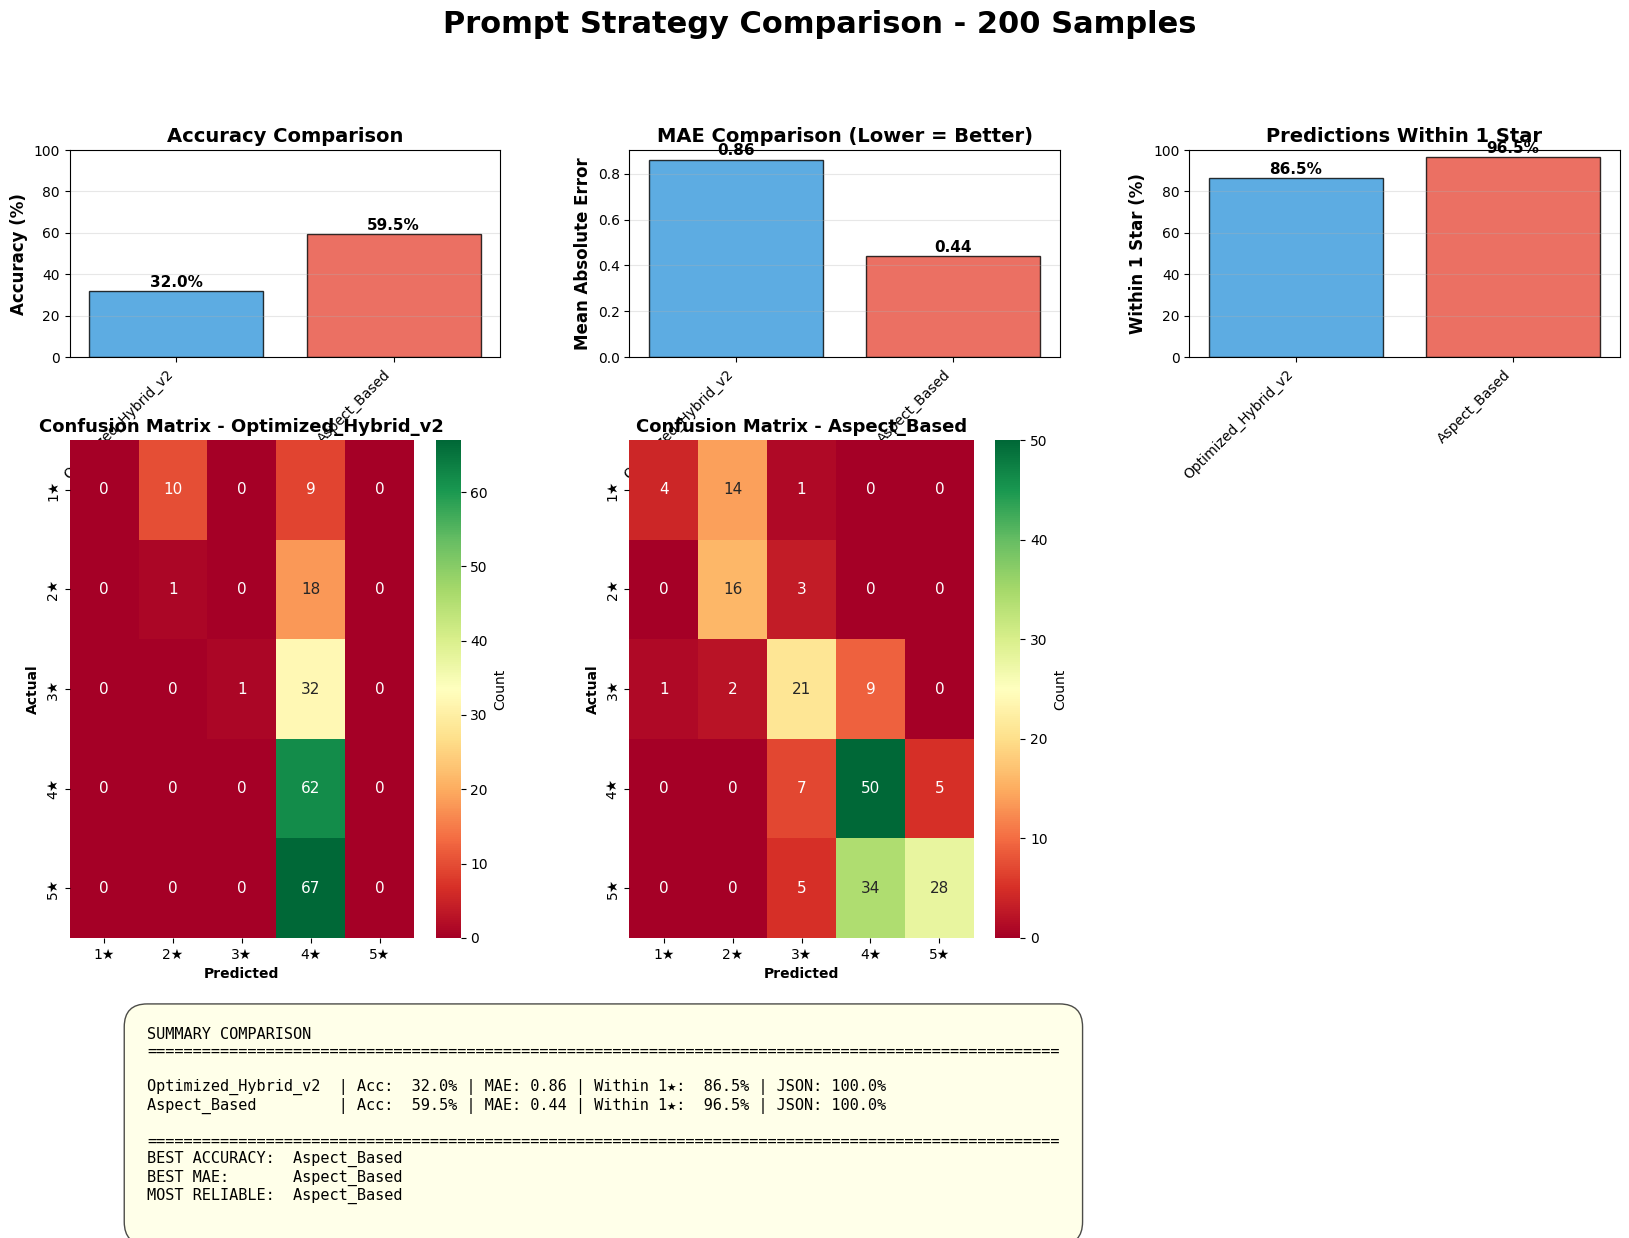


🎉 EVALUATION COMPLETE!

📁 Generated files:
   • Optimized_Hybrid_v2_FINAL.csv
   • Optimized_Hybrid_v2_checkpoint_*.csv
   • Aspect_Based_FINAL.csv
   • Aspect_Based_checkpoint_*.csv
   • prompt_comparison_analysis.png



In [10]:
if __name__ == "__main__":
    try:
        main()
    except KeyboardInterrupt:
        print("\n\n⚠️ Interrupted by user")
    except Exception as e:
        print(f"\n\n❌ Error: {e}")
        import traceback
        traceback.print_exc()